# Aula prática 2 - Fontes de Dados meteorológicos



In [ ]:
# monta o meu drive aqui no colab/máquina virtual
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cd /content/drive/MyDrive/MaterialGeotec/basededados/

/content/drive/MyDrive/MaterialGeotec/basededados


In [ ]:
!ls

coordenadas-inmet.csv  INMET  sicor-interest-data.csv


## SQL que gerou o sicor-interest-data.csv

```
-- =============================================================================
-- CONSULTA INTEGRADA: COPs DEFERIDAS × ZARC × GLEBAS × RCP
-- =============================================================================
--
-- OBJETIVO DIDÁTICO:
-- Esta consulta reúne, em uma única visão, as principais dimensões de análise
-- para avaliar a plausibilidade de pedidos de cobertura do Proagro (COPs)
-- que foram deferidos. Ela integra dados de:
--   1. A COP em si (evento alegado, datas de plantio/colheita, solo, ciclo)
--   2. O Relatório de Comprovação de Perdas - RCP (datas do evento pelo perito)
--   3. O Zoneamento Agrícola de Risco Climático - ZARC (risco do decêndio)
--   4. A geometria da gleba (localização e área calculada)
--
-- Abrange TODAS as culturas e TODOS os anos disponíveis no banco.
-- O cruzamento com o ZARC só retorna dados para soja, milho e trigo
-- (únicas culturas carregadas na tabela zarc); para as demais culturas,
-- as colunas do ZARC virão NULL.
-- =============================================================================

SELECT
    -- =========================================================================
    -- BLOCO 1: Identificação da operação e status do pedido
    -- =========================================================================
    cop.ref_bacen,                                  -- Nº mascarado do contrato
    statuscopproagro.descricao AS status_cop,        -- Status da COP (aqui sempre 'deferida')
    eventoproagro.nome_evento,                       -- Evento meteorológico alegado (ex.: Seca, Geada)
    empreendimento.produto,                          -- Cultura financiada (ex.: soja, milho, trigo)
    ciclocultivarproagro.descricao_ciclo,            -- Grupo de maturação (ex.: Grupo I, II, III)

    -- =========================================================================
    -- BLOCO 2: Datas do evento meteorológico (informadas pelo PERITO no RCP)
    -- =========================================================================
    -- Estas são as datas mais confiáveis sobre o evento, pois foram
    -- estimadas em campo pelo perito. Permitem verificar se o fenômeno
    -- meteorológico coincide com uma fase fenológica vulnerável da cultura.
    -- =========================================================================
    rcp.dt_inicio_evento,                            -- Início do evento segundo o perito
    rcp.dt_fim_evento,                               -- Fim do evento segundo o perito

    -- =========================================================================
    -- BLOCO 3: Datas da COP (informadas pelo produtor/IF)
    -- =========================================================================
    -- Estas datas são declaradas no momento da comunicação de perda.
    -- A comparação entre as datas da COP e do RCP pode revelar
    -- inconsistências relevantes.
    -- =========================================================================
    cop.dt_comunicacao,                              -- Data em que a COP foi registrada
    cop.dt_inicio_plantio,                           -- Início do plantio declarado na COP
    cop.dt_fim_plantio,                              -- Fim do plantio declarado na COP
    cop.dt_inicio_colheita,                          -- Início da colheita declarado na COP
    cop.dt_fim_colheita,                             -- Fim da colheita declarado na COP

    -- =========================================================================
    -- BLOCO 4: Geometria da gleba (localização e área calculada)
    -- =========================================================================
    -- A geometria WKT (SIRGAS 2000, EPSG:4674) é convertida para uma
    -- projeção métrica (EPSG:31983 — SIRGAS/UTM zona 23S) para cálculo
    -- de área em m², depois dividida por 10.000 para obter hectares.
    -- O centróide fornece coordenadas de referência para buscar dados
    -- meteorológicos e de satélite na vizinhança.
    --
    -- NOTA: EPSG:31983 é adequado para o centro-sul do Brasil. Para
    -- glebas fora dessa faixa, a área pode ter distorções. Em uso
    -- operacional, seria necessário selecionar a zona UTM correta.
    -- =========================================================================
    ST_Area(
        ST_Transform(
            ST_GeomFromText(gleba.gt_geometria, 4674),  -- WKT → geometria SIRGAS 2000
            31983                                        -- Reprojeção para UTM 23S (metros)
        )
    ) / 10000.0 AS area_gleba_ha,                    -- Área da gleba em hectares

    gleba.nu_indice,                                 -- Índice da gleba dentro da operação

    ST_X(ST_Centroid(
        ST_GeomFromText(gleba.gt_geometria, 4674)
    )) AS longitude_centroide,                       -- Longitude do centróide (graus decimais)

    ST_Y(ST_Centroid(
        ST_GeomFromText(gleba.gt_geometria, 4674)
    )) AS latitude_centroide,                        -- Latitude do centróide (graus decimais)

    -- =========================================================================
    -- BLOCO 5: ZARC — Zoneamento Agrícola de Risco Climático
    -- =========================================================================
    -- O ZARC indica, para cada combinação município × cultura × grupo ×
    -- solo × decêndio, se o plantio naquela janela tem risco aceitável.
    -- Se risco > 0, o decêndio é recomendado (até 20% de chance de perda).
    -- Se risco = 0, o plantio naquele decêndio NÃO é recomendado.
    --
    -- Uma COP deferida cujo plantio caiu inteiramente em decêndios com
    -- risco = 0 levanta uma questão: a operação não deveria estar
    -- amparada pelo Proagro.
    --
    -- NOTA: Pode haver múltiplas linhas por COP (uma por decêndio
    -- interceptado), o que é esperado e intencional.
    -- =========================================================================
    zarc.data_inicial_decendio,                      -- Início do decêndio ZARC
    zarc.data_final_decendio,                        -- Fim do decêndio ZARC
    zarc.risco AS risco_percentual,                  -- 0 = não recomendado, >0 = recomendado

    -- =========================================================================
    -- BLOCO 6: Contexto espacial e temporal
    -- =========================================================================
    extract(YEAR FROM op.dt_emissao) AS ano_emissao, -- Ano de emissão do contrato
    op_complemento.cd_ibge_municipio,                -- Código IBGE do município
    op.cd_estado                                     -- UF da operação

-- =============================================================================
-- JOINs: montagem da visão integrada
-- =============================================================================

FROM sicor_cop_basico AS cop

-- Ciclo do cultivar: traduz o código numérico para descrição (Grupo I, II, III)
INNER JOIN ciclocultivarproagro
        ON cop.cd_ciclo_cultivar = ciclocultivarproagro.cd_ciclo_cultivar

-- Operação principal: traz datas de emissão, valores, empreendimento, UF
INNER JOIN sicor_operacao_basica_estado AS op
        ON op.ref_bacen = cop.ref_bacen
       AND op.nu_ordem = cop.nu_ordem

-- Complemento da operação: traz o código IBGE do município (essencial para o ZARC)
INNER JOIN sicor_complemento_operacao_basica AS op_complemento
        ON op.ref_bacen = op_complemento.ref_bacen
       AND op.nu_ordem = op_complemento.nu_ordem

-- Evento do Proagro: traduz código numérico para nome (Seca, Geada, etc.)
INNER JOIN eventoproagro
        ON cop.cd_evento = eventoproagro.cd_evento

-- Empreendimento: traz produto, finalidade, atividade, modalidade
INNER JOIN empreendimento
        ON op.cd_empreendimento = empreendimento.cd_empreendimento

-- Status da COP: traduz código para descrição (deferida, indeferida, etc.)
INNER JOIN statuscopproagro
        ON cop.cd_status = statuscopproagro.cd_status

-- =============================================================================
-- Mapeamento produto SICOR → cultura ZARC
-- =============================================================================
-- O SICOR registra 'milho' e 'trigo', mas o ZARC usa 'milho 2ª safra' e
-- 'trigo sequeiro'. Este LATERAL cria a correspondência necessária.
-- Culturas sem mapeamento recebem NULL e não cruzam com o ZARC.
-- =============================================================================
LEFT JOIN LATERAL (
    SELECT CASE LOWER(empreendimento.produto)
               WHEN 'soja'  THEN 'soja'
               WHEN 'milho' THEN 'milho 2ª safra'
               WHEN 'trigo' THEN 'trigo sequeiro'
               ELSE NULL
           END AS cultura_zarc
) mapa ON TRUE

-- =============================================================================
-- ZARC: cruzamento por município + solo + grupo + cultura + sobreposição temporal
-- =============================================================================
-- A condição temporal usa sobreposição de intervalos:
--   plantio_inicio <= decendio_fim AND decendio_inicio <= plantio_fim
-- Isso captura TODOS os decêndios que interceptam o período de plantio,
-- não apenas o decêndio onde cai a data exata de início.
-- Os casts (::text, LOWER) resolvem incompatibilidades de tipo entre as tabelas.
-- =============================================================================
LEFT JOIN zarc
        ON op_complemento.cd_ibge_municipio = zarc.geocodigo
       AND cop.cd_tipo_solo::text = zarc.cod_solo::text
       AND LOWER(ciclocultivarproagro.descricao_ciclo) = LOWER(zarc.grupo)
       AND mapa.cultura_zarc = zarc.cultura
       AND cop.dt_inicio_plantio <= zarc.data_final_decendio
       AND zarc.data_inicial_decendio <= cop.dt_fim_plantio

-- Glebas: geometria WKT da área do empreendimento (pode haver múltiplas por operação)
LEFT JOIN sicor_glebas_wkt AS gleba
        ON cop.ref_bacen = gleba.ref_bacen
       AND cop.nu_ordem = gleba.nu_ordem

-- Complemento da COP: traz CPF do perito e da periciadora
LEFT JOIN sicor_complemento_cop AS complemento_cop
        ON cop.ref_bacen = complemento_cop.ref_bacen
       AND cop.nu_ordem = complemento_cop.nu_ordem

-- RCP (Relatório de Comprovação de Perdas): datas do evento pelo perito
LEFT JOIN sicor_rcp_basico AS rcp
        ON cop.ref_bacen = rcp.ref_bacen
       AND cop.nu_ordem = rcp.nu_ordem

-- =============================================================================
-- FILTROS
-- =============================================================================
-- Restringimos a:
--   • COPs deferidas (status = 2 / 'deferida')
--   • Operações de custeio agrícola de lavoura
--   • Sem filtro de ano nem de cultura (visão completa)
-- =============================================================================
WHERE statuscopproagro.descricao = 'deferida'
  AND empreendimento.finalidade = 'custeio'
  AND empreendimento.atividade  = 'agrícola'
  AND empreendimento.modalidade = 'lavoura'

ORDER BY cop.ref_bacen, cop.nu_ordem;

-- =============================================================================
-- RESULTADO ESPERADO
-- =============================================================================
-- Cada linha representa o cruzamento de uma COP deferida com um decêndio
-- do ZARC e uma gleba da operação. Uma mesma COP pode gerar múltiplas
-- linhas quando:
--   (a) o período de plantio intercepta mais de um decêndio do ZARC, e/ou
--   (b) a operação possui mais de uma gleba (nu_indice > 1).
--
-- As colunas permitem responder, para cada COP deferida:
--
--   TEMPORAL:  As datas de plantio, colheita e evento são coerentes entre
--              si e com o ciclo do cultivar?
--
--   ZARC:      O plantio ocorreu dentro de um decêndio recomendado
--              (risco > 0)? Se todos os decêndios interceptados têm
--              risco = 0, o plantio estava fora da janela ZARC.
--
--   FENOLÓGICO: Dado o início do plantio e o ciclo, em que estádio a
--               cultura estava quando o evento ocorreu? O evento é
--               plausível nessa fase?
--
--   ESPACIAL:  Onde fica a gleba? A área calculada é coerente com a
--              área declarada? As coordenadas permitem buscar dados
--              meteorológicos de estações próximas.
--
-- Para culturas sem correspondência no ZARC (feijão, arroz, algodão etc.),
-- as colunas data_inicial_decendio, data_final_decendio e risco_percentual
-- virão NULL — isso NÃO indica erro, apenas ausência de dados ZARC no banco.
-- =============================================================================
```



In [ ]:
# carrega o csv com Pandas
import pandas as pd
df_sicor = pd.read_csv('sicor-interest-data.csv')

In [ ]:
df_sicor

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
0,516578816,deferida,Chuva excessiva,soja,grupo ii,2024-01-15,2024-03-26,2024-03-26,2023-11-01,2023-11-20,...,11.794878,NaN,NaN,NaN,0.0,-52.452023,-27.643629,2023,4314787,RS
1,3578369,deferida,Chuva excessiva,trigo,grupo iii,NaN,NaN,2014-10-28,2014-06-12,2014-06-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,4317202,RS
2,9982329,deferida,Chuva excessiva,trigo,grupo iii,2017-10-10,2017-10-21,2017-10-23,2017-06-01,2017-07-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,4305306,RS
3,504950111,deferida,Geada,trigo,grupo iii,2017-07-18,2017-07-19,2017-10-02,2017-05-15,2017-05-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,4302204,RS
4,1530852,deferida,Geada,maçã,desabilitado a partir de dezembro de 2016 - in...,NaN,NaN,2013-10-17,2013-08-22,2013-08-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013,4216503,SC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1506624,513677457,deferida,Chuva excessiva,trigo,grupo ii,2022-09-07,2022-09-28,2022-09-30,2022-05-25,2022-05-28,...,3.829991,NaN,NaN,NaN,3.0,-51.829630,-24.667341,2022,4119608,PR
1506625,3216862,deferida,Chuva excessiva,trigo,grupo iii,NaN,NaN,2014-10-14,2014-06-20,2014-06-20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,4311155,RS
1506626,505946863,deferida,Seca,feijão,grupo ii,2018-04-01,2018-04-30,2018-05-02,2018-01-12,2018-01-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,4118501,PR
1506627,514293668,deferida,Seca,soja,não informado,2022-11-13,2023-01-20,2023-01-26,2022-10-04,2022-10-05,...,4.987142,NaN,NaN,NaN,0.0,-53.870834,-25.289374,2022,4115606,PR


In [ ]:
df_sicor['longitude_centroide'].max()

65.66666666666667

In [ ]:
# no resultado da sql tem uma longitudes com valores positivos... não tem como ser aqui no Brasil...
# Então, estou assumindo que essas longitudes estão vindo sem o sinal de negativo na frente...
# Logo, posso ajustar da seguinte forma:
df_sicor['longitude_centroide'] = df_sicor['longitude_centroide'].abs()*-1

In [ ]:
df_sicor['longitude_centroide'].max()

-0.4020011940104167

In [ ]:
# O mesmo acontece na latitude... porém, temos alguns pontos no hemisfério norte... isso pode ser um complicador para nossa análise...
df_sicor['latitude_centroide'].max()

47.89081582738235

In [ ]:
# aqui vamos aplicar um filtro nas nossas e longitude latitudes que sejam coerentes com as dimensões do brasil
df_sicor = df_sicor.loc[df_sicor['latitude_centroide'][(df_sicor['latitude_centroide'] >= -34) & (df_sicor['latitude_centroide'] <= 6)].index]

In [ ]:
df_sicor = df_sicor.loc[df_sicor['longitude_centroide'][(df_sicor['longitude_centroide'] >= -75) & (df_sicor['longitude_centroide'] <= -33)].index]

In [ ]:
df_sicor

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
0,516578816,deferida,Chuva excessiva,soja,grupo ii,2024-01-15,2024-03-26,2024-03-26,2023-11-01,2023-11-20,...,11.794878,NaN,NaN,NaN,0.0,-52.452023,-27.643629,2023,4314787,RS
11,509939195,deferida,Seca,trigo,grupo ii,2020-09-27,2020-10-15,2020-10-15,2020-05-11,2020-06-26,...,42.185319,NaN,NaN,NaN,0.0,-55.256329,-27.941107,2020,4315107,RS
12,512442149,deferida,Seca,soja,grupo iii,2021-11-20,2022-02-01,2022-03-08,2021-10-27,2021-10-28,...,18.317065,NaN,NaN,NaN,0.0,-52.957163,-29.195475,2021,4301206,RS
14,514182145,deferida,Seca,milho,grupo iii,2022-10-20,2023-02-09,2023-02-09,2022-09-15,2022-10-15,...,38.934856,NaN,NaN,NaN,0.0,-52.193300,-28.242409,2022,4312138,RS
15,513532353,deferida,Chuva excessiva,feijão,grupo iii,2022-05-05,2022-06-06,2022-06-06,2022-02-23,2022-02-25,...,4.073600,NaN,NaN,NaN,0.0,-52.511612,-27.740961,2022,4310900,RS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1506622,513677457,deferida,Chuva excessiva,trigo,grupo ii,2022-09-07,2022-09-28,2022-09-30,2022-05-25,2022-05-28,...,2.239017,NaN,NaN,NaN,1.0,-51.836406,-24.658579,2022,4119608,PR
1506623,513677457,deferida,Chuva excessiva,trigo,grupo ii,2022-09-07,2022-09-28,2022-09-30,2022-05-25,2022-05-28,...,6.050870,NaN,NaN,NaN,2.0,-51.832343,-24.667800,2022,4119608,PR
1506624,513677457,deferida,Chuva excessiva,trigo,grupo ii,2022-09-07,2022-09-28,2022-09-30,2022-05-25,2022-05-28,...,3.829991,NaN,NaN,NaN,3.0,-51.829630,-24.667341,2022,4119608,PR
1506627,514293668,deferida,Seca,soja,não informado,2022-11-13,2023-01-20,2023-01-26,2022-10-04,2022-10-05,...,4.987142,NaN,NaN,NaN,0.0,-53.870834,-25.289374,2022,4115606,PR


In [ ]:
# aqui filtrando apenas as cops de SOJA da nossa base em .CSV
df = df_sicor[(df_sicor['produto'] == 'soja')]


In [ ]:
df

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
0,516578816,deferida,Chuva excessiva,soja,grupo ii,2024-01-15,2024-03-26,2024-03-26,2023-11-01,2023-11-20,...,11.794878,NaN,NaN,NaN,0.0,-52.452023,-27.643629,2023,4314787,RS
12,512442149,deferida,Seca,soja,grupo iii,2021-11-20,2022-02-01,2022-03-08,2021-10-27,2021-10-28,...,18.317065,NaN,NaN,NaN,0.0,-52.957163,-29.195475,2021,4301206,RS
28,514249818,deferida,Seca,soja,grupo ii,2022-12-15,2023-01-14,2023-03-17,2022-11-08,2022-11-08,...,14.198728,2022-11-01,2022-11-10,20.0,0.0,-52.273137,-31.433564,2022,4322327,RS
43,512730678,deferida,Seca,soja,grupo iii,2021-12-10,2022-03-04,2022-03-04,2021-11-20,2021-11-25,...,12.223630,NaN,NaN,NaN,0.0,-53.883023,-28.551591,2021,4302220,RS
46,507254241,deferida,Seca,soja,grupo iii,2018-11-30,2019-01-02,2019-01-03,2018-09-24,2018-09-30,...,18.802488,NaN,NaN,NaN,0.0,-53.660583,-24.282302,2018,4102000,PR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1506616,514462397,deferida,Seca,soja,grupo i,2022-12-20,2023-03-15,2023-03-16,2022-11-20,2022-12-05,...,6.179601,2022-11-11,2022-11-20,30.0,0.0,-54.736953,-27.988724,2022,4303707,RS
1506617,514462397,deferida,Seca,soja,grupo i,2022-12-20,2023-03-15,2023-03-16,2022-11-20,2022-12-05,...,15.844761,2022-11-11,2022-11-20,30.0,1.0,-54.722667,-28.005341,2022,4303707,RS
1506618,514462397,deferida,Seca,soja,grupo i,2022-12-20,2023-03-15,2023-03-16,2022-11-20,2022-12-05,...,9.216185,2022-11-11,2022-11-20,30.0,2.0,-54.730425,-27.988547,2022,4303707,RS
1506627,514293668,deferida,Seca,soja,não informado,2022-11-13,2023-01-20,2023-01-26,2022-10-04,2022-10-05,...,4.987142,NaN,NaN,NaN,0.0,-53.870834,-25.289374,2022,4115606,PR


In [ ]:
# Agora, vamos contar quantas vezes uma coordenada solicitou seguro
# faz a contagem por groupby
contagem = (df
    .groupby(['longitude_centroide', 'latitude_centroide']) # Agrupa as linhas do DataFrame por pares únicos de longitude, latitude.
    .size() # Conta quantas linhas existem em cada grupo
    .reset_index(name='contagem') # Transforma o resultado de Series para DataFrame, nomeando a coluna de 'contagem'
    .sort_values('contagem', ascending=False)  # Ordena do maior para o menor
)

contagem

,longitude_centroide,latitude_centroide,contagem
95048,-53.808481,-24.587729,37
95475,-53.803998,-24.584196,37
95485,-53.803898,-24.585192,36
303544,-51.577824,-25.784480,28
303484,-51.580712,-25.780798,28
...,...,...,...
121822,-53.523477,-26.108156,1
121821,-53.523505,-25.350283,1
121820,-53.523525,-28.369344,1
121819,-53.523533,-28.401059,1


In [ ]:
absurdos = contagem[contagem['contagem']> 10]

In [ ]:
absurdos

,longitude_centroide,latitude_centroide,contagem
95048,-53.808481,-24.587729,37
95475,-53.803998,-24.584196,37
95485,-53.803898,-24.585192,36
303544,-51.577824,-25.784480,28
303484,-51.580712,-25.780798,28
...,...,...,...
318344,-49.559648,-27.610406,11
185186,-53.017810,-27.775671,11
318279,-49.566056,-27.607691,11
318325,-49.561076,-27.608139,11


In [ ]:
# instalando a biblioteca que faz mapas no Python...
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 36.7 MB/s eta 0:00:00


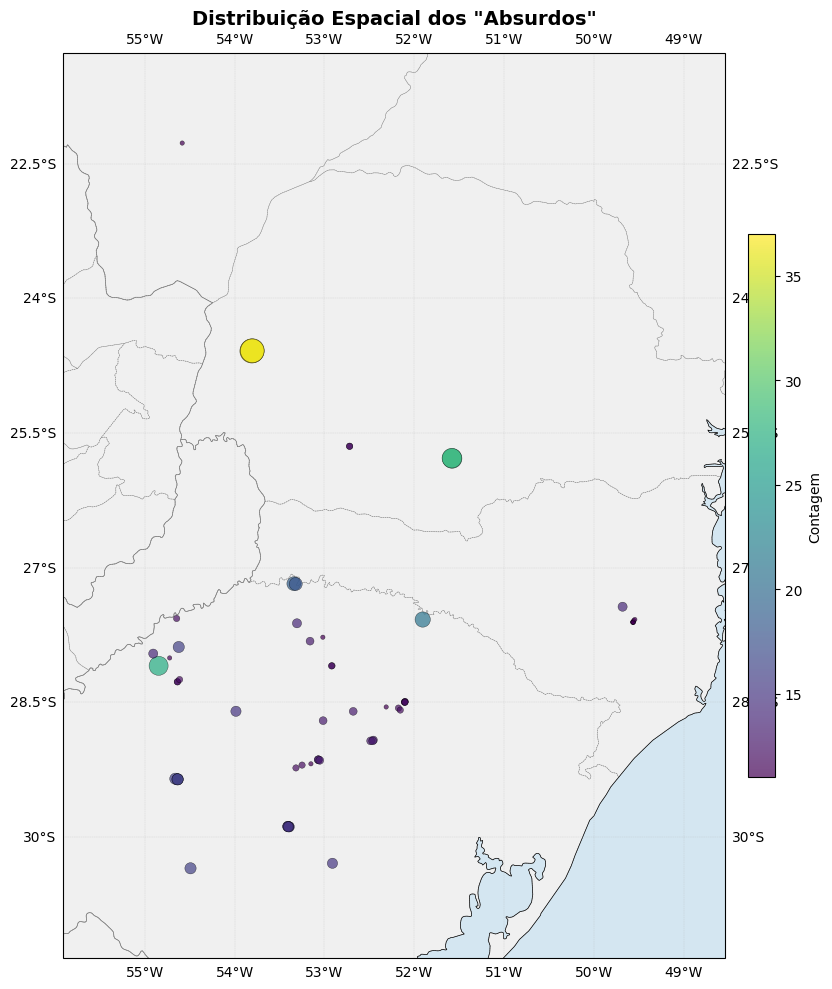

In [ ]:
# vamos ver a distribuição desses valores estranhos...
# e aqui já vou aproveitar para fazer um "mapa" em Python

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

proj = ccrs.PlateCarree() # nossa projeção favorita → WGS84

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': proj})

# Limites do mapa (baseado nos dados com margem)
margin = 1 # aqui é uma margem de 1° de lat e longitude em relação ao min max de lat lon
ax.set_extent([
    absurdos['longitude_centroide'].min() - margin,
    absurdos['longitude_centroide'].max() + margin,
    absurdos['latitude_centroide'].min() - margin,
    absurdos['latitude_centroide'].max() + margin
], crs=proj)

# Features do mapa
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

# Normalização para tamanho e cor
sizes = np.interp(absurdos['contagem'],
                  [absurdos['contagem'].min(), absurdos['contagem'].max()],
                  [10, 300])

sc = ax.scatter(
    absurdos['longitude_centroide'],
    absurdos['latitude_centroide'],
    c=absurdos['contagem'],
    s=sizes,
    cmap='viridis',
    alpha=0.7,
    edgecolors='k',
    linewidths=0.3,
    transform=proj,
    zorder=5
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02, label='Contagem')
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
ax.set_title('Distribuição Espacial dos "Absurdos"', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# aqui vamos pegar o caso mais emblemático... aquela coordenada que pediu a maior quantidade de seguros...
absurdos.iloc[0]

,95048
longitude_centroide,-53.808481
latitude_centroide,-24.587729
contagem,37.000000


In [ ]:
# vamos ver que tanto de COP foi pedida para a primeira coordenada do absurdo...
coord = absurdos[['longitude_centroide', 'latitude_centroide']].iloc[0].values
df[(df['longitude_centroide'] == coord[0]) & (df['latitude_centroide'] == coord[1])]

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
612239,514778310,deferida,Seca,soja,grupo i,2022-12-25,2023-01-29,2023-02-03,2022-10-04,2022-10-04,...,4.05417,2022-10-01,2022-10-10,20.0,2.0,-53.808481,-24.587729,2022,4127700,PR
1391715,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-12-21,2022-12-31,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391718,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-12-11,2022-12-20,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391721,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-12-01,2022-12-10,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391724,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-11-21,2022-11-30,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391727,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-11-11,2022-11-20,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391730,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-11-01,2022-11-10,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391733,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-10-21,2022-10-31,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391736,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-10-11,2022-10-20,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR
1391914,516203036,deferida,Seca,soja,grupo i,2023-12-10,2024-01-11,2024-01-11,2010-09-26,2023-10-02,...,4.05417,2022-10-01,2022-10-10,20.0,2.0,-53.808481,-24.587729,2023,4127700,PR


# Hipotese sobre esses resultados:

É possível que os pedidos foram realizados por uma coperativa... colocando essas coordenadas no google maps, caímos numa localidade específica...

In [ ]:
# Então vamos filtrar por um único plantio por latitude e longitude
contagem_filtrada = (df
    .groupby(['longitude_centroide', 'latitude_centroide'])['dt_comunicacao'] # além das coordenadas, agora também filtramos a data
    .nunique() # ao invés de contar, pegamos as datas únicas
    .reset_index(name='contagem')
    .sort_values('contagem', ascending=False)
)
contagem_filtrada

,longitude_centroide,latitude_centroide,contagem
227501,-52.726593,-28.785903,4
12869,-54.824230,-27.881350,4
61900,-54.135039,-28.023736,4
181127,-53.038444,-28.849930,4
211212,-52.875159,-28.978132,4
...,...,...,...
112649,-53.632044,-24.511161,1
112648,-53.632057,-25.852033,1
112647,-53.632059,-26.561469,1
112646,-53.632065,-24.039108,1


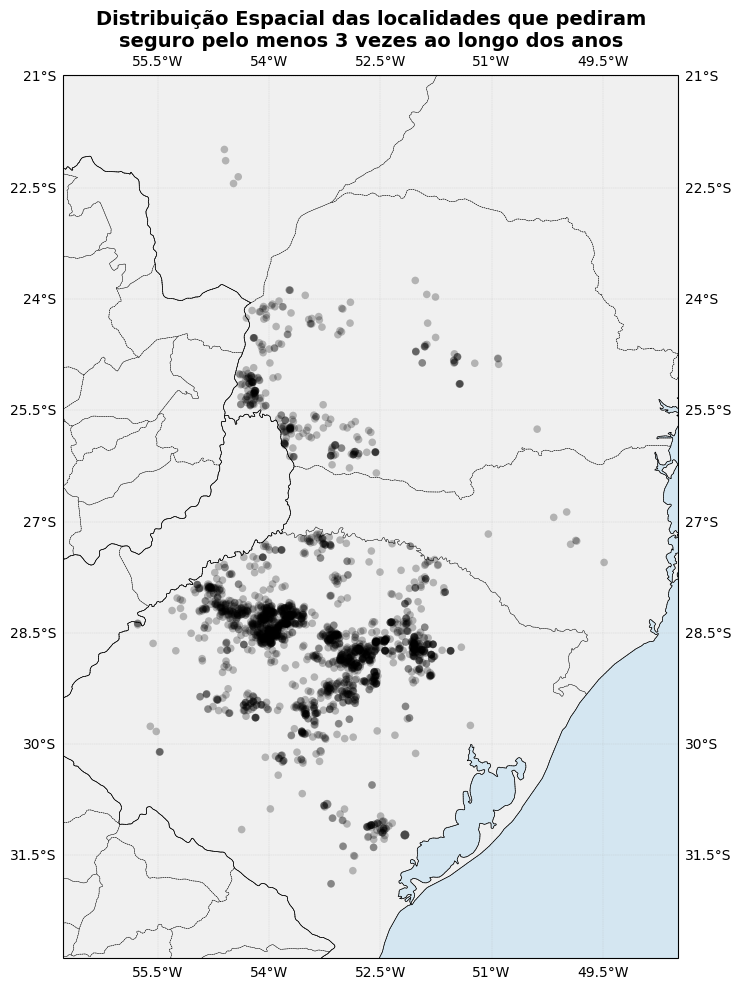

In [ ]:
# repetindo o mesmo mapa para essas coordenadas
# Filtrando contagem > 2
contagem_filtrada = contagem_filtrada[contagem_filtrada['contagem'] > 2]

# cria uma nova figura
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection':proj})

# Limites do mapa (baseado nos dados com margem)
margin = 1
ax.set_extent([
    contagem_filtrada['longitude_centroide'].min() - margin,
    contagem_filtrada['longitude_centroide'].max() + margin,
    contagem_filtrada['latitude_centroide'].min() - margin,
    contagem_filtrada['latitude_centroide'].max() + margin
], crs=ccrs.PlateCarree())

# Features do mapa
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='k')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='k', linestyle='--')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1')

sc = ax.scatter(
    contagem_filtrada['longitude_centroide'],
    contagem_filtrada['latitude_centroide'],
    c='k',
    s=contagem_filtrada['contagem']*10,
    alpha=0.25,
    edgecolors='none',
    linewidths=0,
    transform=proj,
    zorder=5
)

ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle='--')
ax.set_title('Distribuição Espacial das localidades que pediram\nseguro pelo menos 3 vezes ao longo dos anos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Transformando o nosso mapa, em um mapa interativo com Folium!

In [ ]:
# Vamos transformar isso num mapa interativo...
import folium
from folium.plugins import HeatMap

# Centro do mapa
center_lat = contagem_filtrada['latitude_centroide'].mean()
center_lon = contagem_filtrada['longitude_centroide'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

# Dados para o heatmap: [lat, lon, peso]
heat_data = contagem_filtrada[['latitude_centroide', 'longitude_centroide', 'contagem']].values.tolist()

HeatMap(heat_data, radius=10, blur=5, max_zoom=13).add_to(m)

m

## Vamos ao que é o ponto central da nossa disciplina: **Buscar uma coordenada de interesse e ver se o pedido é coerente com os dados meteorológicos**

In [ ]:
coord = contagem_filtrada[['longitude_centroide', 'latitude_centroide']].iloc[0].values
lat = coord[1]
lon = coord[0]
df_azarado = df[(df['longitude_centroide'] == lon) & (df['latitude_centroide'] == lat)]
df_azarado

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
629117,516467384,deferida,Seca,soja,grupo ii,2024-01-19,2024-02-12,2024-04-01,2023-11-21,2023-11-25,...,33.113296,NaN,NaN,NaN,0.0,-52.726593,-28.785903,2023,4307500,RS
823389,512282130,deferida,Seca,soja,grupo i,2021-11-15,2022-02-28,2022-03-21,2021-11-08,2021-11-11,...,33.113296,NaN,NaN,NaN,1.0,-52.726593,-28.785903,2021,4307500,RS
1430171,514337048,deferida,Seca,soja,grupo ii,2022-12-01,2023-03-20,2023-03-27,2022-11-26,2022-11-28,...,33.113296,2022-11-21,2022-11-30,20.0,0.0,-52.726593,-28.785903,2022,4307500,RS
1456170,508616115,deferida,Seca,soja,grupo iii,2019-12-15,2020-03-12,2020-03-12,2019-11-15,2019-11-28,...,33.113296,NaN,NaN,NaN,0.0,-52.726593,-28.785903,2019,4307500,RS


In [ ]:
# Destacando essa essa localidade no heatmap Folium
folium.Marker([lat,lon], popup="Local COP recorrente").add_to(m)
m

# Agora, vamos encontrar a estação do INMET mais próxima

In [ ]:
# Aqui vamos fazer algumas "mágicas" com Linux/Bash/Shell
!ls

coordenadas-inmet.csv  INMET  sicor-interest-data.csv


In [ ]:
!head INMET/2024/INMET_S_SC_A806_FLORIANOPOLIS_01-01-2024_A_31-12-2024.CSV

REGIAO:;S
UF:;SC
ESTACAO:;FLORIANOPOLIS
CODIGO (WMO):;A806
LATITUDE:;-27,6025
LONGITUDE:;-48,61999999
ALTITUDE:;4,87
DATA DE FUNDACAO:;22/01/03
Data;Hora UTC;PRECIPITA��O TOTAL, HOR�RIO (mm);PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB);PRESS�O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB);PRESS�O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB);RADIACAO GLOBAL (Kj/m�);TEMPERATURA DO AR - BULBO SECO, HORARIA (�C);TEMPERATURA DO PONTO DE ORVALHO (�C);TEMPERATURA M�XIMA NA HORA ANT. (AUT) (�C);TEMPERATURA M�NIMA NA HORA ANT. (AUT) (�C);TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (�C);TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (�C);UMIDADE REL. MAX. NA HORA ANT. (AUT) (%);UMIDADE REL. MIN. NA HORA ANT. (AUT) (%);UMIDADE RELATIVA DO AR, HORARIA (%);VENTO, DIRE��O HORARIA (gr) (� (gr));VENTO, RAJADA MAXIMA (m/s);VENTO, VELOCIDADE HORARIA (m/s);
2024/01/01;0000 UTC;0;1016,6;1016,6;1016,2;;23,2;17,6;23,2;23;18,1;17,4;73;70;71;120;5,6;0;


In [ ]:
# quero criar um arquivo só com as latitudes e longitude das estações
# para isso vou combinar uma sequência de comandos...
!grep 'CODIGO' -A2 INMET/2024/*.CSV | sed 's/^.*CSV//; s/,/./g' | cut -d';' -f2 | grep -v '^--' | paste - - - -d',' > coordenadas-inmet.csv

In [ ]:
!ls

In [ ]:
!head coordenadas-inmet.csv

A001,-15.78944444,-47.92583332
A042,-15.59972221,-48.1311111
A045,-15.596491,-47.625801
A046,-15.93527777,-48.13749999
A047,-16.012222,-47.557417
A002,-16.64277777,-49.22027777
A003,-17.74499999,-49.10166666
A005,-13.30944444,-49.11749999
A011,-18.96916666,-50.63333333
A012,-16.26055555,-47.96694443


## Voltando para o Python e buscando as coordenadas próximas!

In [ ]:
inmet_coords = pd.read_csv('coordenadas-inmet.csv', header=0, names=['cod', 'latitude', 'longitude'])
inmet_coords

,cod,latitude,longitude
0,A042,-15.599722,-48.131111
1,A045,-15.596491,-47.625801
2,A046,-15.935278,-48.137500
3,A047,-16.012222,-47.557417
4,A002,-16.642778,-49.220278
...,...,...,...
559,A867,-28.931353,-49.497920
560,A868,-26.950833,-48.761944
561,A870,-27.678611,-49.041944
562,A895,-27.085311,-52.635711


### Agora, quando nós vamos buscar coordenadas próximas, temos que usar a equção de Harvesine, dada por:

$$d = 2r \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_2 - \phi_1}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\lambda_2 - \lambda_1}{2}\right)}\right)$$

Onde:

- $d$ = distância entre os dois pontos
- $r$ = raio da Terra (≈ 6.371 km)
- $\phi_1, \phi_2$ = latitudes dos pontos 1 e 2 (em radianos)
- $\lambda_1, \lambda_2$ = longitudes dos pontos 1 e 2 (em radianos)


### Vamos criar um função python para isso

In [ ]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.asin(math.sqrt(a))

In [ ]:
# Aplicando a função no nosso ponto de interesse e NO DATA FRAME DE LOCALIDADES DO INMET
inmet_coords['estacoes_proximas'] = inmet_coords.apply(lambda row: haversine(lat, lon, row['latitude'], row['longitude']), axis=1).sort_values()

In [ ]:
inmet_coords.sort_values('estacoes_proximas')

,cod,latitude,longitude,estacoes_proximas
516,A837,-28.859211,-52.542387,19.709950
530,A883,-28.653333,-53.111944,40.365725
518,A839,-28.226667,-52.403611,69.734434
536,A894,-28.704722,-51.870833,83.916437
522,A853,-28.603440,-53.673597,94.571611
...,...,...,...,...
117,A128,-0.987222,-62.924167,3275.158463
122,A244,0.694167,-51.403889,3281.055969
119,A134,-0.125207,-67.061246,3532.414917
303,A135,2.816944,-60.690833,3615.419990


In [ ]:
top3 = inmet_coords.sort_values('estacoes_proximas').head(3)

In [ ]:
# inclue esse top 3 estações próximas no mapa Folium, só pra gente ter uma noção de distância...
for _, row in top3.iterrows():
  print(row['cod'], row['latitude'], row['longitude'], row['estacoes_proximas'])
  folium.Marker(
        [row['latitude'], row['longitude']],
        popup=f"{ row['cod']} - {row['estacoes_proximas']:.1f} km",
        tooltip=row['cod'],
        icon=folium.Icon(color="orange", icon="cloud")
    ).add_to(m)

A837 -28.859211 -52.542387 19.709949887370207
A883 -28.65333333 -53.11194444 40.365725111779945
A839 -28.22666666 -52.40361111 69.73443372720449


In [ ]:
m

In [ ]:
# Agora sim, sabemos quem são os códigos das estações próximas... logo, vamos abrir os arquivos dessas estações...
top3.cod.to_list()

['A837', 'A883', 'A839']

In [ ]:
import glob
# Nomes padronizados para todas as 19 colunas
COLUNAS = [
    'DATA', 'HORA',
    'PREC',          # Precipitação total horária (mm)
    'PATM',          # Pressão atmosférica estação (mB)
    'PATM_MAX',      # Pressão atm máxima hora ant (mB)
    'PATM_MIN',      # Pressão atm mínima hora ant (mB)
    'RAD',           # Radiação global (KJ/m²)
    'TEMP',          # Temperatura bulbo seco (°C)
    'TD',            # Temperatura ponto de orvalho (°C)
    'TMAX',          # Temperatura máxima hora ant (°C)
    'TMIN',          # Temperatura mínima hora ant (°C)
    'TD_MAX',        # Temp orvalho máxima hora ant (°C)
    'TD_MIN',        # Temp orvalho mínima hora ant (°C)
    'UR_MAX',        # Umidade relativa máxima (%)
    'UR_MIN',        # Umidade relativa mínima (%)
    'UR',            # Umidade relativa horária (%)
    'VENTO_DIR',     # Direção do vento (graus)
    'VENTO_RAJ',     # Rajada máxima (m/s)
    'VENTO_VEL',     # Velocidade horária (m/s)
]


STN = []
for stn in top3.cod.to_list():
    files = glob.glob(f'INMET/*/*{stn}*.CSV')
    for f in files:
        df_stn = pd.read_csv(f, encoding='latin1', sep=';', decimal=',', skiprows=8)
        print(f)

        # Remove última coluna vazia (trailing ;)
        df_stn = df_stn.loc[:, ~df_stn.columns.str.startswith('Unnamed')]

        # renomeia as colunas de acordo com a posição
        df_stn.columns = COLUNAS[:len(df_stn.columns)]

        # Normaliza colunas da data e da hora
        df_stn.rename(columns={df_stn.columns[0]: 'DATA', df_stn.columns[1]: 'HORA'}, inplace=True)

        # Garante que é Series (não DataFrame)
        df_stn['HORA'] = (df_stn['HORA']
                          .astype(str)
                          .str.strip()
                          .str.replace(' UTC', '', regex=False)
                          .str.replace(r'^(\d{2})(\d{2})$', r'\1:\2', regex=True))

        df_stn['DATA'] = df_stn['DATA'].astype(str).str.replace('/', '-')
        df_stn['COD'] = stn
        df_stn.index = pd.to_datetime(df_stn['DATA'] + ' ' + df_stn['HORA'])

        STN.append(df_stn)

df_all = pd.concat(STN)

INMET/2014/INMET_S_RS_A837_SOLEDADE_01-01-2014_A_31-12-2014.CSV
INMET/2015/INMET_S_RS_A837_SOLEDADE_01-01-2015_A_31-12-2015.CSV
INMET/2016/INMET_S_RS_A837_SOLEDADE_01-01-2016_A_31-12-2016.CSV
INMET/2017/INMET_S_RS_A837_SOLEDADE_01-01-2017_A_31-12-2017.CSV
INMET/2018/INMET_S_RS_A837_SOLEDADE_01-01-2018_A_31-12-2018.CSV
INMET/2019/INMET_S_RS_A837_SOLEDADE_01-01-2019_A_31-12-2019.CSV
INMET/2020/INMET_S_RS_A837_SOLEDADE_01-01-2020_A_31-12-2020.CSV
INMET/2021/INMET_S_RS_A837_SOLEDADE_01-01-2021_A_31-12-2021.CSV
INMET/2022/INMET_S_RS_A837_SOLEDADE_01-01-2022_A_31-12-2022.CSV
INMET/2023/INMET_S_RS_A837_SOLEDADE_01-01-2023_A_31-12-2023.CSV
INMET/2024/INMET_S_RS_A837_SOLEDADE_01-01-2024_A_31-12-2024.CSV
INMET/2025/INMET_S_RS_A837_SOLEDADE_01-01-2025_A_30-11-2025.CSV
INMET/2025/INMET_S_RS_A837_SOLEDADE_01-01-2025_A_31-12-2025.CSV
INMET/2014/INMET_S_RS_A883_IBIRUBA_01-01-2014_A_31-12-2014.CSV
INMET/2015/INMET_S_RS_A883_IBIRUBA_01-01-2015_A_31-12-2015.CSV
INMET/2016/INMET_S_RS_A883_IBIRUBA_01-01-2

In [ ]:
!head INMET/*/*A837*

==> INMET/2014/INMET_S_RS_A837_SOLEDADE_01-01-2014_A_31-12-2014.CSV <==
REGI�O:;S
UF:;RS
ESTA��O:;SOLEDADE
CODIGO (WMO):;A837
LATITUDE:;-28,85361111
LONGITUDE:;-52,55833333
ALTITUDE:;667
DATA DE FUNDA��O (YYYY-MM-DD):;2008-03-01
DATA (YYYY-MM-DD);HORA (UTC);PRECIPITA��O TOTAL, HOR�RIO (mm);PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB);PRESS�O ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB);PRESS�O ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB);RADIACAO GLOBAL (KJ/m�);TEMPERATURA DO AR - BULBO SECO, HORARIA (�C);TEMPERATURA DO PONTO DE ORVALHO (�C);TEMPERATURA M�XIMA NA HORA ANT. (AUT) (�C);TEMPERATURA M�NIMA NA HORA ANT. (AUT) (�C);TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (�C);TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (�C);UMIDADE REL. MAX. NA HORA ANT. (AUT) (%);UMIDADE REL. MIN. NA HORA ANT. (AUT) (%);UMIDADE RELATIVA DO AR, HORARIA (%);VENTO, DIRE��O HORARIA (gr) (� (gr));VENTO, RAJADA MAXIMA (m/s);VENTO, VELOCIDADE HORARIA (m/s);
2014-01-01;00:00;0;933,3;933,8;933,3;-9999;23,2;21,1;

In [ ]:
df_all

,DATA,HORA,PREC,PATM,PATM_MAX,PATM_MIN,RAD,TEMP,TD,TMAX,TMIN,TD_MAX,TD_MIN,UR_MAX,UR_MIN,UR,VENTO_DIR,VENTO_RAJ,VENTO_VEL,COD
2014-01-01 00:00:00,2014-01-01,00:00,0.0,933.3,933.8,933.3,-9999.0,23.2,21.1,23.8,23.1,21.3,20.9,88.0,85.0,88.0,86.0,5.4,2.9,A837
2014-01-01 01:00:00,2014-01-01,01:00,0.0,933.6,933.6,933.1,-9999.0,23.2,20.6,23.3,23.0,21.1,20.5,88.0,84.0,85.0,58.0,7.2,3.3,A837
2014-01-01 02:00:00,2014-01-01,02:00,0.0,933.0,933.7,933.0,-9999.0,22.7,19.7,23.4,22.7,20.6,19.7,85.0,83.0,83.0,82.0,6.4,4.4,A837
2014-01-01 03:00:00,2014-01-01,03:00,0.0,932.5,933.0,932.5,-9999.0,23.0,19.0,23.0,22.7,19.7,19.0,83.0,78.0,78.0,53.0,7.9,5.5,A837
2014-01-01 04:00:00,2014-01-01,04:00,0.0,932.1,932.7,932.1,-9999.0,22.8,19.9,23.2,22.7,20.0,19.1,84.0,78.0,84.0,60.0,8.8,4.8,A837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,2025-12-31,19:00,0.0,933.9,933.9,933.9,481.7,24.2,21.9,24.2,24.2,21.9,21.9,89.0,89.0,89.0,214.0,1.6,1.0,A839
2025-12-31 20:00:00,2025-12-31,20:00,0.0,933.4,933.4,933.4,171.5,23.9,21.9,23.9,23.9,21.9,21.9,90.0,90.0,90.0,182.0,1.6,1.3,A839
2025-12-31 21:00:00,2025-12-31,21:00,0.0,933.4,933.4,933.4,5.9,22.9,22.0,22.9,22.9,22.0,22.0,95.0,95.0,95.0,225.0,2.2,1.0,A839
2025-12-31 22:00:00,2025-12-31,22:00,0.0,934.0,934.0,934.0,0.0,22.3,21.8,22.3,22.3,21.8,21.8,98.0,98.0,98.0,51.0,1.4,1.2,A839


In [ ]:
df_prec = df_all[['COD','PREC']]
df_prec

,COD,PREC
2014-01-01 00:00:00,A837,0.0
2014-01-01 01:00:00,A837,0.0
2014-01-01 02:00:00,A837,0.0
2014-01-01 03:00:00,A837,0.0
2014-01-01 04:00:00,A837,0.0
...,...,...
2025-12-31 19:00:00,A839,0.0
2025-12-31 20:00:00,A839,0.0
2025-12-31 21:00:00,A839,0.0
2025-12-31 22:00:00,A839,0.0


In [ ]:
df_prec = df_prec.pivot_table(index=df_prec.index, columns='COD', values='PREC')
df_prec

COD,A837,A839,A883
2014-01-01 00:00:00,0.0,0.2,0.0
2014-01-01 01:00:00,0.0,0.2,0.0
2014-01-01 02:00:00,0.0,0.0,0.0
2014-01-01 03:00:00,0.0,0.0,0.0
2014-01-01 04:00:00,0.0,0.0,0.0
...,...,...,...
2025-12-31 19:00:00,NaN,0.0,11.4
2025-12-31 20:00:00,NaN,0.0,6.3
2025-12-31 21:00:00,NaN,0.0,0.0
2025-12-31 22:00:00,NaN,0.0,0.0


In [ ]:
df_azarado

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,dt_inicio_plantio,dt_fim_plantio,...,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude_centroide,latitude_centroide,ano_emissao,cd_ibge_municipio,cd_estado
629117,516467384,deferida,Seca,soja,grupo ii,2024-01-19,2024-02-12,2024-04-01,2023-11-21,2023-11-25,...,33.113296,NaN,NaN,NaN,0.0,-52.726593,-28.785903,2023,4307500,RS
823389,512282130,deferida,Seca,soja,grupo i,2021-11-15,2022-02-28,2022-03-21,2021-11-08,2021-11-11,...,33.113296,NaN,NaN,NaN,1.0,-52.726593,-28.785903,2021,4307500,RS
1430171,514337048,deferida,Seca,soja,grupo ii,2022-12-01,2023-03-20,2023-03-27,2022-11-26,2022-11-28,...,33.113296,2022-11-21,2022-11-30,20.0,0.0,-52.726593,-28.785903,2022,4307500,RS
1456170,508616115,deferida,Seca,soja,grupo iii,2019-12-15,2020-03-12,2020-03-12,2019-11-15,2019-11-28,...,33.113296,NaN,NaN,NaN,0.0,-52.726593,-28.785903,2019,4307500,RS


In [ ]:
# Agora vamos somar a precipitação no período do azar
evento_azarado = df_azarado.iloc[0]
dt_inicio_evento = evento_azarado['dt_inicio_evento']
dt_fim_evento = evento_azarado['dt_fim_evento']
df_prec.loc[dt_inicio_evento:dt_fim_evento].sum()

,0
COD,
A837,25.2
A839,53.2
A883,8.6


In [ ]:
# quantos dias de azar?
import datetime as dt
dt_inicio_evento = dt.datetime.strptime(dt_inicio_evento,'%Y-%m-%d')
dt_fim_evento = dt.datetime.strptime(dt_fim_evento,'%Y-%m-%d')

print(dt_fim_evento - dt_inicio_evento)

24 days, 0:00:00


In [ ]:
# chuva total da safra
dt_plantio = evento_azarado['dt_inicio_plantio']
dt_colheita = evento_azarado['dt_fim_colheita']
df_prec.loc[dt_plantio:dt_colheita].sum()

,0
COD,
A837,687.0
A839,1049.2
A883,862.2


# Vamos estimar o estádio fenológico dessa soja, com base no acúmulo de graus dia...


In [ ]:
import numpy as np

# Parâmetros da soja
TB = 10   # Temperatura base (°C)
TM = 38   # Temperatura máxima (°C) - acima disso, não contribui

def graus_dia_diario(tmax, tmin, tb=TB, tm=TM):
    """
    Calcula graus-dia diário pelo método da média simples com limites.

    GD = ((Tmax + Tmin) / 2) - Tb

    Com correções:
    - Se Tmax > Tm, usa Tm
    - Se Tmin < Tb, usa Tb
    - Se GD < 0, retorna 0
    """
    tmax = np.minimum(tmax, tm)
    tmin = np.maximum(tmin, tb)
    gd = ((tmax + tmin) / 2) - tb
    return np.maximum(gd, 0)


def graus_dia_acumulado(df, col_tmax='TMAX', col_tmin='TMIN', col_prec='PREC',
                         data_semeadura=None, gd_maturacao=1500):
    """
    Calcula GD acumulado e precipitação acumulada por fase fenológica.
    """
    # Reamostra para diário
    df_dia = df.resample('D').agg({col_tmax: 'max', col_tmin: 'min', col_prec: 'sum'})
    df_dia.dropna(subset=[col_tmax, col_tmin], inplace=True)

    # Filtra a partir da semeadura
    if data_semeadura:
        df_dia = df_dia.loc[data_semeadura:]

    # Calcula GD
    df_dia['GD'] = graus_dia_diario(df_dia[col_tmax], df_dia[col_tmin])
    df_dia['GD_ACUM'] = df_dia['GD'].cumsum()

    # Fases fenológicas
    fases = {
        'VE - Emergência':         50,
        'V2 - 2º nó':            130,
        'V4 - 4º nó':            230,
        'R1 - Início floração':   550,
        'R3 - Início enchimento': 750,
        'R5 - Enchimento grão':   950,
        'R7 - Maturidade fisiol.':1250,
        'R8 - Maturação plena':   gd_maturacao,
    }

    # Identifica data de cada fase
    df_dia['FASE'] = ''
    datas_fases = {}
    for fase, gd_ref in fases.items():
        mask = df_dia['GD_ACUM'] >= gd_ref
        if mask.any():
            idx = mask.idxmax()
            df_dia.loc[idx, 'FASE'] = fase
            datas_fases[fase] = idx

    # Calcula precipitação acumulada entre fases
    fases_ordem = list(fases.keys())
    prec_por_fase = {}
    for i, fase in enumerate(fases_ordem):
        if fase not in datas_fases:
            break
        dt_ini = datas_fases[fases_ordem[i - 1]] if i > 0 and fases_ordem[i - 1] in datas_fases else df_dia.index[0]
        dt_fim = datas_fases[fase]
        prec_por_fase[fase] = {
            'data_inicio': dt_ini,
            'data_fim': dt_fim,
            'dias': (dt_fim - dt_ini).days,
            'tmax': df_dia.loc[dt_ini:dt_fim, col_tmax].max(),
            'prec_mm': df_dia.loc[dt_ini:dt_fim, col_prec].sum(),
            'gd_acum': df_dia.loc[dt_fim, 'GD_ACUM'],
        }

    df_fases = pd.DataFrame(prec_por_fase).T
    df_fases.index.name = 'FASE'

    return df_dia, fases, df_fases

In [ ]:
# Supondo que df_all já existe com TMAX, TMIN por estação
# Para uma estação específica:
stn = 'A837'
df_stn = df_all[df_all['COD'] == 'A837'][['TMAX', 'TMIN', 'PREC']].copy()

#dt_plantio = dt.datetime.strptime(dt_plantio, '%Y-%m-%d')
data_semeadura=dt_plantio


df_gd, fases, df_fases = graus_dia_acumulado(df_stn, data_semeadura=dt_plantio)

# Mostra fases atingidas
print("-" * 75)
print(f"stação: {stn} | Semeadura: {data_semeadura}")
print("-" * 75)
df_fases


---------------------------------------------------------------------------
stação: A837 | Semeadura: 2023-11-21
---------------------------------------------------------------------------


,data_inicio,data_fim,dias,tmax,prec_mm,gd_acum
FASE,,,,,,
VE - Emergência,2023-11-21 00:00:00,2023-11-25 00:00:00,4,31.7,42.4,51.75
V2 - 2º nó,2023-11-25 00:00:00,2023-12-01 00:00:00,6,35.9,62.8,133.9
V4 - 4º nó,2023-12-01 00:00:00,2023-12-10 00:00:00,9,35.9,89.0,231.15
R1 - Início floração,2023-12-10 00:00:00,2024-01-03 00:00:00,24,35.5,150.8,551.1
R3 - Início enchimento,2024-01-03 00:00:00,2024-01-18 00:00:00,15,32.7,107.4,753.15
R5 - Enchimento grão,2024-01-18 00:00:00,2024-02-04 00:00:00,17,32.0,54.4,950.75
R7 - Maturidade fisiol.,2024-02-04 00:00:00,2024-02-26 00:00:00,22,33.9,102.0,1258.8
R8 - Maturação plena,2024-02-26 00:00:00,2024-03-17 00:00:00,20,32.0,132.6,1512.2


In [ ]:
print(f'Evento Adverso: {dt_inicio_evento} a {dt_fim_evento}, total de {dt_fim_evento-dt_inicio_evento}')
dt_meio = dt_inicio_evento + (dt_fim_evento - dt_inicio_evento) / 2
print(dt_meio)
df_fases[(df_fases['data_inicio'] <= dt_meio) & (df_fases['data_fim'] >= dt_meio)]

Evento Adverso: 2024-01-19 00:00:00 a 2024-02-12 00:00:00, total de 24 days, 0:00:00
2024-01-31 00:00:00


,data_inicio,data_fim,dias,tmax,prec_mm,gd_acum
FASE,,,,,,
R5 - Enchimento grão,2024-01-18 00:00:00,2024-02-04 00:00:00,17,32.0,54.4,950.75


In [ ]:
# Valores hipotéticos precipitação e GDD por estádio
prec_esperada = {
    'VE - Emergência':          25,   # ~20–30 mm apenas na germinação/emergência
    'V2 - 2º nó':               30,   # mm adicionais em VE→V2
    'V4 - 4º nó':               35,   # mm adicionais em V2→V4
    'R1 - Início floração':     53,   # mm adicionais em V4→R1
    'R3 - Início enchimento':  117,   # mm adicionais em R1→R3 (~metade de R1→R5)
    'R5 - Enchimento grão':    125,   # mm adicionais em R3→R5 (completa R1→R5 = 242 mm)
    'R7 - Maturidade fisiol.': 132,   # mm adicionais em R5→R7
    'R8 - Maturação plena':     43,   # mm adicionais em R7→R8
}

fases_gdd = {
    'VE - Emergência':          50,
    'V2 - 2º nó':             130,
    'V4 - 4º nó':             230,
    'R1 - Início floração':    550,
    'R3 - Início enchimento':  750,
    'R5 - Enchimento grão':    950,
    'R7 - Maturidade fisiol.':1250,
    'R8 - Maturação plena':   1500,
}

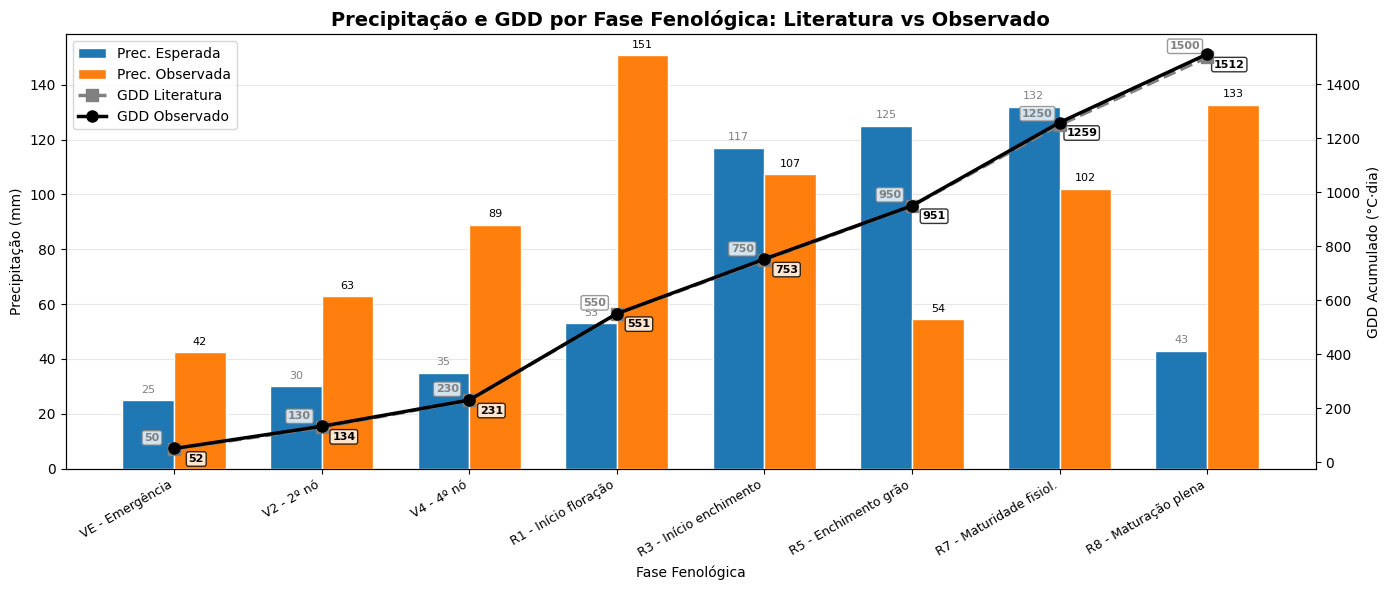

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fases = list(fases_gdd.keys())
gdd_literatura = list(fases_gdd.values())
gdd_observado = df_fases['gd_acum'].values

# Extract precipitation values in the correct order for prec_esperada
prec_esperada_list = [prec_esperada[fase] for fase in fases]
# Extract observed precipitation from df_fases
prec_observada = df_fases['prec_mm'].values

x = np.arange(len(fases))

fig, ax = plt.subplots(figsize=(14, 6))
ax2 = ax.twinx()

# Barras de precipitação
width = 0.35
bars1 = ax.bar(x - width/2, prec_esperada_list, width, label='Prec. Esperada', color='tab:blue', edgecolor='white', zorder=3)
bars2 = ax.bar(x + width/2, prec_observada, width, label='Prec. Observada', color='tab:orange', edgecolor='white', zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8, color='grey')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8, color='k')

# Linhas de GDD
ax2.plot(x, gdd_literatura, color='grey', marker='s', linewidth=2.5, markersize=8,
         linestyle='--', label='GDD Literatura', zorder=4)
ax2.plot(x, gdd_observado, color='k', marker='o', linewidth=2.5, markersize=8,
         label='GDD Observado', zorder=4)

for i in range(len(fases)):
  ax2.text(i - 0.15, gdd_literatura[i] + 30, f'{gdd_literatura[i]:.0f}',
          ha='center', fontsize=8, color='grey', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='grey', alpha=0.8))
  ax2.text(i + 0.15, gdd_observado[i] - 50, f'{gdd_observado[i]:.0f}',
          ha='center', fontsize=8, color='k', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='k', alpha=0.8))

ax.set_xlabel('Fase Fenológica')
ax.set_ylabel('Precipitação (mm)')
ax2.set_ylabel('GDD Acumulado (°C·dia)')
ax.set_title('Precipitação e GDD por Fase Fenológica: Literatura vs Observado', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fases, rotation=30, ha='right', fontsize=9)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Foi a aula de hoje
print(lat, lon)


-28.78590273427753 -52.726593359283584
